Dataset Shape:
(101, 11)

Missing Values
gender                0
age                   1
course                0
year                  0
cgpa                  0
marital_status        0
depression            0
anxiety               0
panic_attack          0
visited_specialist    0
dtype: int64

Depression Distribution
depression
0    65
1    35
Name: count, dtype: int64


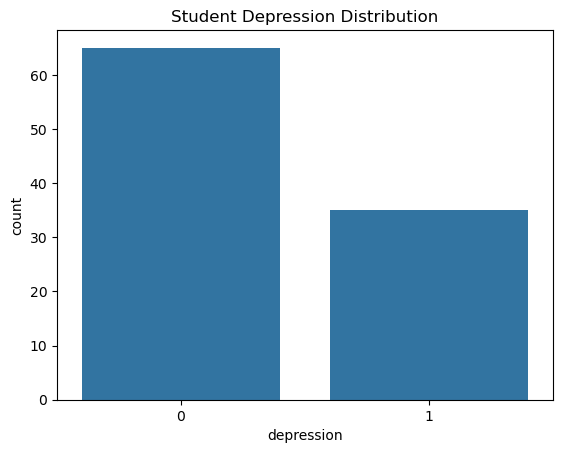


LOGISTIC REGRESSION RESULTS
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.79      0.85      0.81        13
           1       0.67      0.57      0.62         7

    accuracy                           0.75        20
   macro avg       0.73      0.71      0.72        20
weighted avg       0.74      0.75      0.75        20


RANDOM FOREST RESULTS
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.80      0.57      0.67         7

    accuracy                           0.80        20
   macro avg       0.80      0.75      0.76        20
weighted avg       0.80      0.80      0.79        20



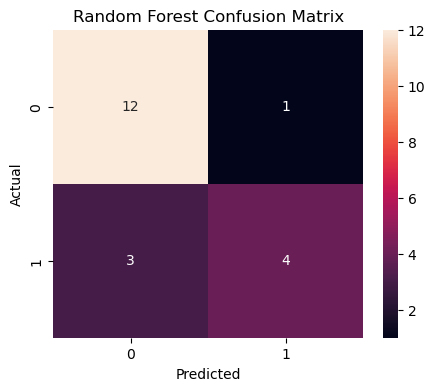

Random Forest Selected

Model Saved Successfully

Prediction Result
Student Low Mental Health Risk
Risk Probability: 0.605


In [1]:
# ============================================================
# STUDENT MENTAL HEALTH DETECTION USING MACHINE LEARNING
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


import joblib



# =========================
# LOAD DATASET
# =========================


data = pd.read_csv(
    "../data/Student Mental health.csv"
)


print("Dataset Shape:")
print(data.shape)


data.head()



# =========================
# REMOVE TIMESTAMP
# =========================


data.drop(
    "Timestamp",
    axis=1,
    inplace=True
)



# =========================
# RENAME COLUMNS
# =========================


data.rename(
columns={

'Choose your gender':'gender',

'Age':'age',

'What is your course?':'course',

'Your current year of Study':'year',

'What is your CGPA?':'cgpa',

'Marital status':'marital_status',

'Do you have Depression?':'depression',

'Do you have Anxiety?':'anxiety',

'Do you have Panic attack?':'panic_attack',

'Did you seek any specialist for a treatment?':'visited_specialist'

},
inplace=True
)



# =========================
# REMOVE MISSING VALUES
# =========================


print("\nMissing Values")
print(data.isnull().sum())


data.dropna(inplace=True)



# =========================
# CLEAN TEXT DATA
# =========================


for col in data.select_dtypes(include='object'):

    data[col]=(
        data[col]
        .astype(str)
        .str.strip()
        .str.title()
    )



# =========================
# FIX YEAR VALUES
# =========================


data['year']=data['year'].replace({

'Year 1':'Year 1',
'Year 2':'Year 2',
'Year 3':'Year 3',
'Year 4':'Year 4'

})



# =========================
# CONVERT TARGET LABEL
# =========================


data['depression']=data['depression'].map({

'Yes':1,
'No':0

})


print("\nDepression Distribution")
print(data['depression'].value_counts())



# =========================
# DATA VISUALIZATION
# =========================


sns.countplot(
x=data['depression']
)

plt.title(
"Student Depression Distribution"
)

plt.show()



# =========================
# FEATURES AND TARGET
# =========================


X=data.drop(
'depression',
axis=1
)


y=data['depression']



# =========================
# DEFINE FEATURES
# =========================


categorical_features=[

'gender',

'course',

'year',

'cgpa',

'marital_status',

'anxiety',

'panic_attack',

'visited_specialist'

]


numeric_features=[

'age'

]



# =========================
# PREPROCESSING PIPELINE
# =========================


preprocessor=ColumnTransformer(

transformers=[

(
'categorical',
OneHotEncoder(
handle_unknown='ignore'
),
categorical_features
),


(
'numerical',
'passthrough',
numeric_features
)

]

)



# =========================
# TRAIN TEST SPLIT
# =========================


X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y

)



# ==================================================
# MODEL 1 : LOGISTIC REGRESSION
# ==================================================


logistic_model=Pipeline(

steps=[

(
'preprocessor',
preprocessor
),


(
'classifier',
LogisticRegression(
max_iter=1000
)
)

]

)



logistic_model.fit(

X_train,

y_train

)



logistic_prediction=logistic_model.predict(

X_test

)



logistic_accuracy=accuracy_score(

y_test,

logistic_prediction

)



print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print(
"Accuracy:",
logistic_accuracy
)


print(
classification_report(
y_test,
logistic_prediction
)
)





# ==================================================
# MODEL 2 : RANDOM FOREST
# ==================================================


rf_model=Pipeline(

steps=[

(
'preprocessor',
preprocessor
),


(
'classifier',
RandomForestClassifier(

n_estimators=200,

random_state=42

)

)

]

)



rf_model.fit(

X_train,

y_train

)



rf_prediction=rf_model.predict(

X_test

)



rf_accuracy=accuracy_score(

y_test,

rf_prediction

)



print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print(

"Accuracy:",

rf_accuracy

)


print(

classification_report(

y_test,

rf_prediction

)

)



# =========================
# CONFUSION MATRIX
# =========================


cm=confusion_matrix(

y_test,

rf_prediction

)


plt.figure(
figsize=(5,4)
)


sns.heatmap(

cm,

annot=True,

fmt='d'

)


plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.title(
"Random Forest Confusion Matrix"
)


plt.show()



# =========================
# SAVE BEST MODEL
# =========================


if rf_accuracy >= logistic_accuracy:

    final_model = rf_model

    print(
    "Random Forest Selected"
    )

else:

    final_model = logistic_model

    print(
    "Logistic Regression Selected"
    )



joblib.dump(

final_model,

"student_mental_health_model.pkl"

)



print(
"\nModel Saved Successfully"
)



# ==================================================
# TEST NEW STUDENT PREDICTION
# ==================================================


model = joblib.load(

"student_mental_health_model.pkl"

)



new_student=pd.DataFrame({

'gender':['Female'],

'age':[20],

'course':['Engineering'],

'year':['Year 2'],

'cgpa':['3.50 - 4.00'],

'marital_status':['No'],

'anxiety':['Yes'],

'panic_attack':['Yes'],

'visited_specialist':['No']

})



prediction=model.predict(

new_student

)



probability=model.predict_proba(

new_student

)



print("\nPrediction Result")


if prediction[0]==1:

    print(
    "⚠ Student Mental Health Risk Detected"
    )

else:

    print(
    "Student Low Mental Health Risk"
    )


print(

"Risk Probability:",

probability.max()

)